### 1.Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 2. Data Overview


#### 2.1 Taxi data

In [3]:
# Load dữ liệu
df_taxi = pd.read_csv('../data/raw/yellow_tripdata_2016-03.csv')

def data_overview(df, name):
    print(f"--- Overview: {name} ---")
    print(f"Shape: {df.shape}")
    print(df.info())
    print(f"Missing Values:\n{df.isnull().sum()}")
    print(f"Duplicate Rows: {df.duplicated().sum()}")
    print("-" * 30)

data_overview(df_taxi, "NYC Taxi")


--- Overview: NYC Taxi ---
Shape: (12210952, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12210952 entries, 0 to 12210951
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RatecodeID             int64  
 8   store_and_fwd_flag     object 
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
dtypes: float64(12), int64(4), object(3)
memory usage: 1.7+ GB
None
Missing Valu

### Nhận xét
* Dữ liệu NYC Taxi có quy mô khổng lồ với hơn 12.2 triệu dòng trong một tháng và hoàn toàn không có dữ liệu thiếu. Dữ liệu có một vài dòng trùng lặp cần loại bỏ.

#### 2.2 Metro Traffic data

In [4]:
# Load dữ liệu
df_traffic = pd.read_csv('../data/raw/Metro_Interstate_Traffic_Volume.csv')

def data_overview(df, name):
    print(f"--- Overview: {name} ---")
    print(f"Shape: {df.shape}")
    print(df.info())
    print(f"Missing Values:\n{df.isnull().sum()}")
    print(f"Duplicate Rows: {df.duplicated().sum()}")
    print("-" * 30)

data_overview(df_traffic, "Metro Traffic")

--- Overview: Metro Traffic ---
Shape: (48204, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB
None
Missing Values:
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_t

### Nhận xét
*  Dữ liệu Metro Traffic có hơn 48.000 dòng; cột ngày lễ chứa nhiều giá trị rỗng nhưng điều này hoàn toàn hợp lý vì đại diện cho ngày thường. Dữ liệu có một vài dòng trùng lặp cần loại bỏ.

### 3. Univariate Analysis

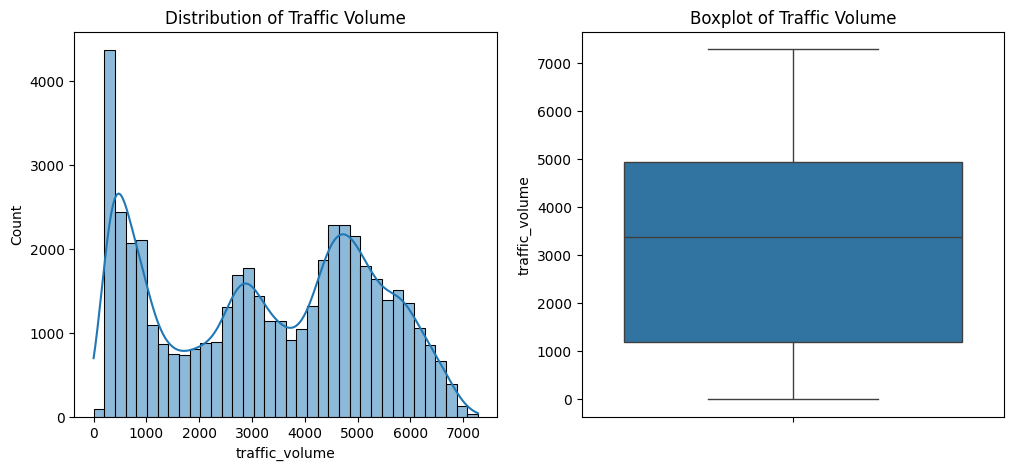

               temp       rain_1h       snow_1h    clouds_all  traffic_volume
count  48204.000000  48204.000000  48204.000000  48204.000000    48204.000000
mean     281.205870      0.334264      0.000222     49.362231     3259.818355
std       13.338232     44.789133      0.008168     39.015750     1986.860670
min        0.000000      0.000000      0.000000      0.000000        0.000000
25%      272.160000      0.000000      0.000000      1.000000     1193.000000
50%      282.450000      0.000000      0.000000     64.000000     3380.000000
75%      291.806000      0.000000      0.000000     90.000000     4933.000000
max      310.070000   9831.300000      0.510000    100.000000     7280.000000
weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64


In [5]:
# Ví dụ phân tích Traffic Volume
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_traffic['traffic_volume'], kde=True)
plt.title('Distribution of Traffic Volume')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_traffic['traffic_volume'])
plt.title('Boxplot of Traffic Volume')
plt.show()

# Thống kê mô tả
print(df_traffic.describe())
print(df_traffic['weather_main'].value_counts())

### Nhận xét
* Lưu lượng giao thông phân bố theo dạng đa đỉnh do sự thay đổi linh hoạt giữa ngày và đêm. Về mặt ngoại lệ, dữ liệu thời tiết ghi nhận một số lỗi cảm biến nghiêm trọng như nhiệt độ giảm xuống tuyệt đối 0 độ Kelvin hay lượng mưa cao bất thường. Nhìn chung, khu vực đo đạc chủ yếu có thời tiết nhiều mây và trời quang.

### 4. Time-based Analysis

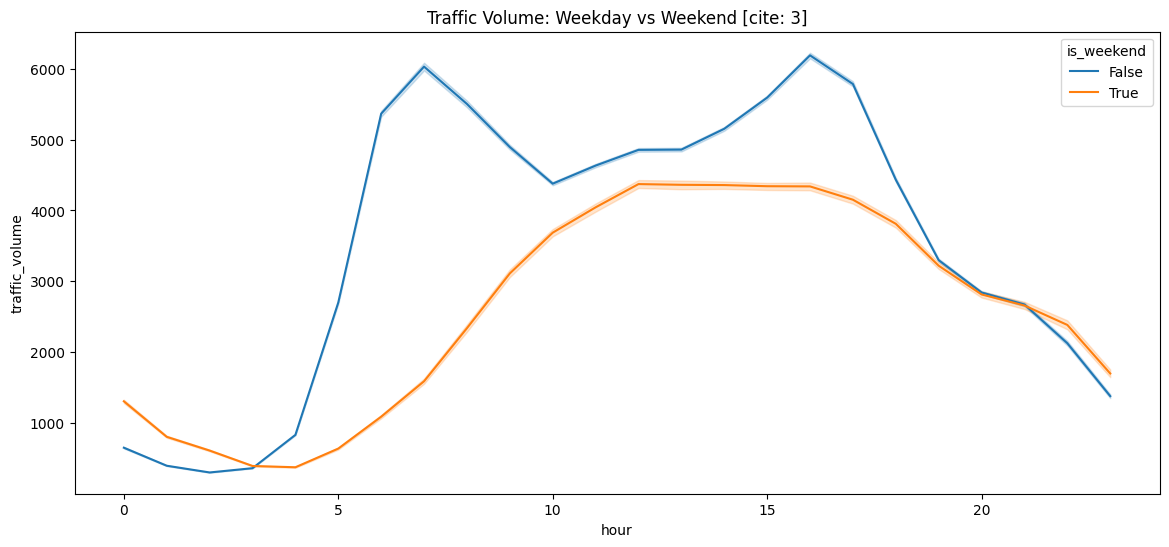

In [6]:
# Tiền xử lý datetime
df_taxi['tpep_pickup_datetime'] = pd.to_datetime(df_taxi['tpep_pickup_datetime'])
df_taxi['hour'] = df_taxi['tpep_pickup_datetime'].dt.hour
df_taxi['dayofweek'] = df_taxi['tpep_pickup_datetime'].dt.dayofweek

df_traffic['date_time'] = pd.to_datetime(df_traffic['date_time'])
df_traffic['hour'] = df_traffic['date_time'].dt.hour
df_traffic['dayofweek'] = df_traffic['date_time'].dt.dayofweek

# So sánh lưu lượng theo giờ giữa Weekday và Weekend
plt.figure(figsize=(14, 6))
df_traffic['is_weekend'] = df_traffic['dayofweek'] >= 5
sns.lineplot(data=df_traffic, x='hour', y='traffic_volume', hue='is_weekend')
plt.title('Traffic Volume: Weekday vs Weekend [cite: 3]')
plt.show()

### Nhận xét
* Lưu lượng giao thông thể hiện quy luật khác biệt rõ rệt giữa ngày thường và cuối tuần. Ngày làm việc trong tuần có hai đỉnh cao điểm vào buổi sáng và chiều tối. Trong khi đó, ngày cuối tuần chỉ có một đỉnh lưu lượng kéo dài từ trưa đến chiều.

### 5.Bivariate Analysis & Correlation

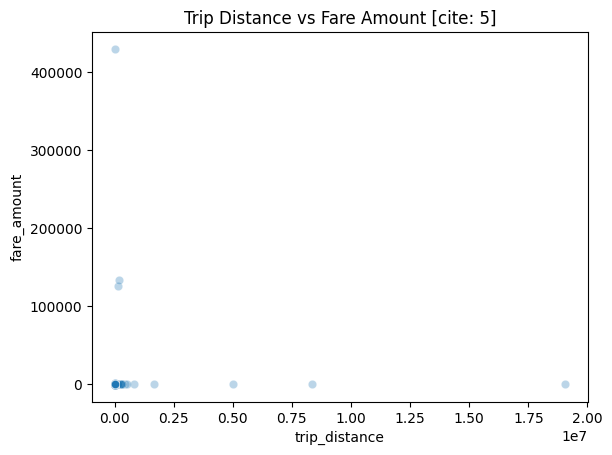

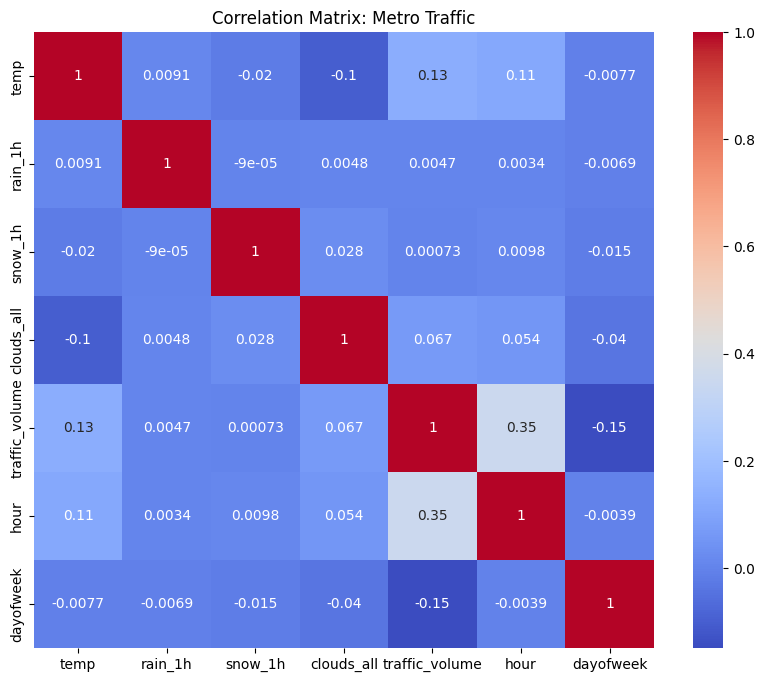

In [7]:
# Taxi: Quan hệ giữa Distance và Fare
sns.scatterplot(data=df_taxi, x='trip_distance', y='fare_amount', alpha=0.3)
plt.title('Trip Distance vs Fare Amount [cite: 5]')
plt.show()

# Heatmap tương quan cho Traffic
plt.figure(figsize=(10, 8))
sns.heatmap(df_traffic.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix: Metro Traffic')
plt.show()

### Nhận xét
* Đối với dữ liệu Taxi, quãng đường và giá tiền có mối tương quan tuyến tính dương rất mạnh, ngoại trừ các mức giá cố định dành cho tuyến đường ra sân bay. 

* Đối với dữ liệu Traffic, thời tiết không tác động tuyến tính trực tiếp đến lưu lượng xe, cho thấy mức độ ảnh hưởng mang tính chất phức tạp hơn.

### 6. Interaction Feature & Interaction

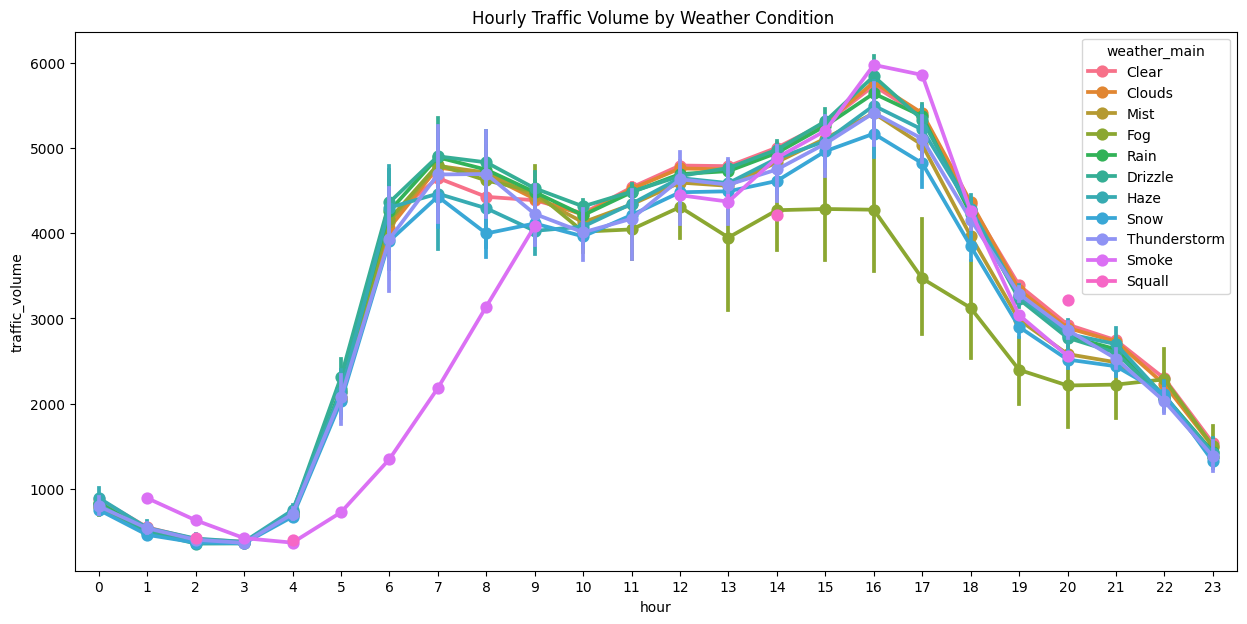

In [8]:
# Interaction: Tác động của thời tiết đến lưu lượng theo giờ
plt.figure(figsize=(15, 7))
sns.pointplot(data=df_traffic, x='hour', y='traffic_volume', hue='weather_main')
plt.title('Hourly Traffic Volume by Weather Condition ')
plt.show()

### Nhận xét
* Thời gian trong ngày là yếu tố quyết định cốt lõi đối với lưu lượng xe. Các điều kiện thời tiết cực đoan chỉ đóng vai trò thứ yếu, làm giảm nhẹ lượng xe lưu thông nhưng không phá vỡ quy luật hai đỉnh của giờ cao điểm.

### 7. Spatial Analysis


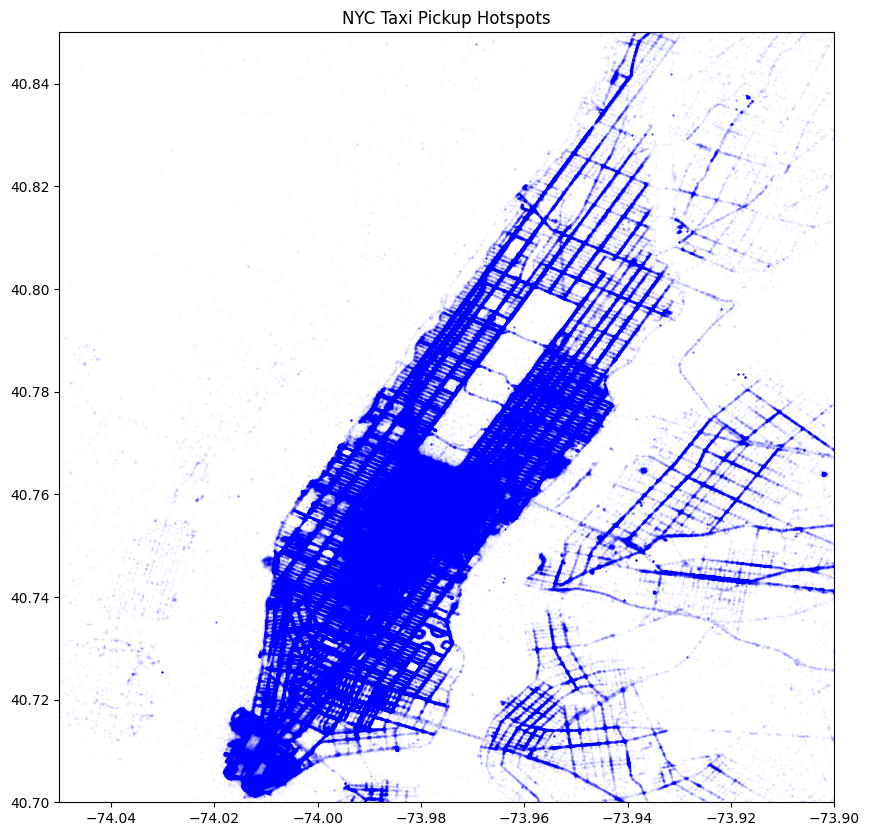

In [9]:
# Visual nhanh tọa độ đón khách (Pickup)
# Lọc bỏ tọa độ lỗi (0,0) theo kế hoạch đồ án [cite: 4]
df_taxi_clean = df_taxi[(df_taxi['pickup_longitude'] != 0) & (df_taxi['pickup_latitude'] != 0)]

plt.figure(figsize=(10, 10))
plt.scatter(df_taxi_clean['pickup_longitude'], df_taxi_clean['pickup_latitude'], s=0.1, alpha=0.1, color='blue')
plt.xlim([-74.05, -73.90])
plt.ylim([40.70, 40.85])
plt.title('NYC Taxi Pickup Hotspots')
plt.show()

### Nhận xét
* Bản đồ phân tán tọa độ khẳng định khu vực trung tâm Manhattan là điểm nóng có mật độ đón trả khách bằng taxi dày đặc nhất. Các luồng di chuyển nhánh chủ yếu nối thẳng đến các sân bay quốc tế.

### 8. Time Series Pattern

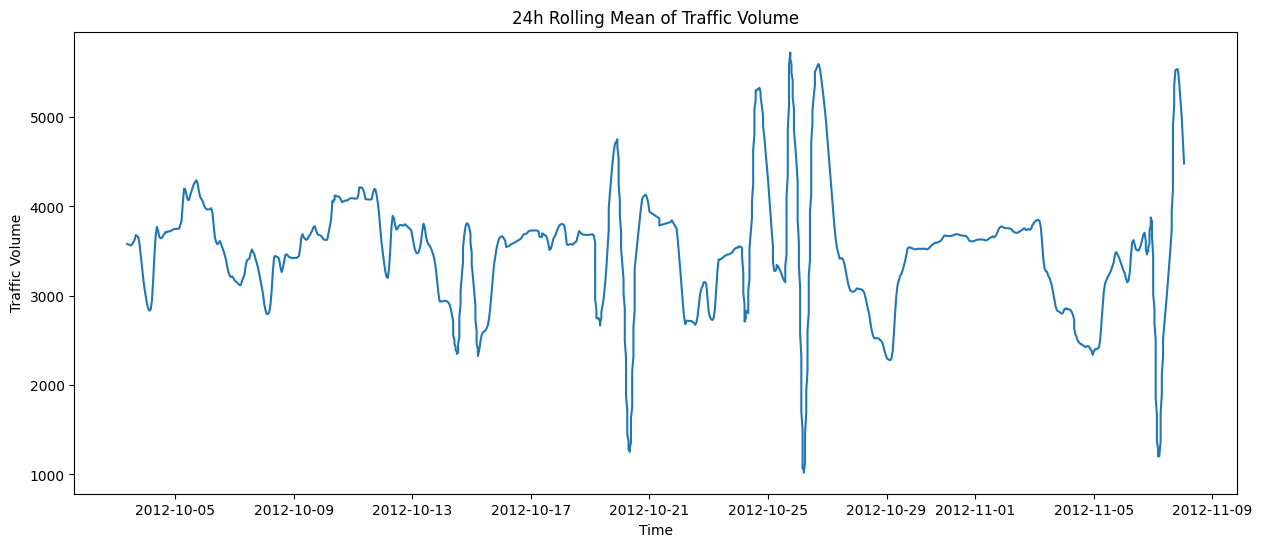

In [10]:
# Xu hướng lưu lượng giao thông dài hạn (Trung bình trượt 24h)
df_traffic_sorted = df_traffic.sort_values('date_time')
df_traffic_sorted['rolling_traffic'] = df_traffic_sorted['traffic_volume'].rolling(window=24).mean()

plt.figure(figsize=(15, 6))
plt.plot(df_traffic_sorted['date_time'][:1000], df_traffic_sorted['rolling_traffic'][:1000])
plt.title('24h Rolling Mean of Traffic Volume')
plt.xlabel('Time')
plt.ylabel('Traffic Volume')
plt.show()

### Nhận xét
* Phân tích trung bình trượt 24 giờ chỉ ra chu kỳ giao thông lặp lại cực kỳ đều đặn theo tuần. Tổng lưu lượng xe luôn sụt giảm mạnh và tạo thành các vùng đáy biểu đồ vào những ngày cuối tuần hoặc dịp nghỉ lễ.